In [1]:
import numpy as np
import pandas as pd
import random
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.em_transformer_rework import EM

np.set_printoptions(precision=4)

In [2]:
# data params
n_biomarkers = 10
t_max = 40 # was 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.05
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 2 #3,4,5
rng = np.random.RandomState(75)

For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.

a = 1.8531667261047913, b = 1.5312904682995265


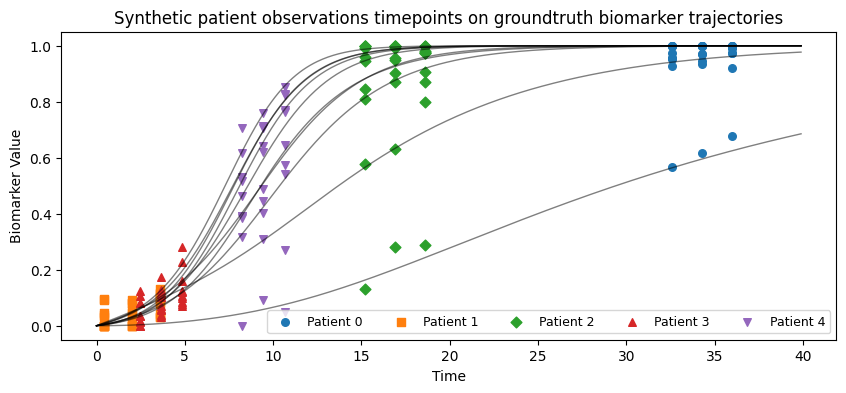

a = 1.8531667261047913, b = 1.5312904682995265


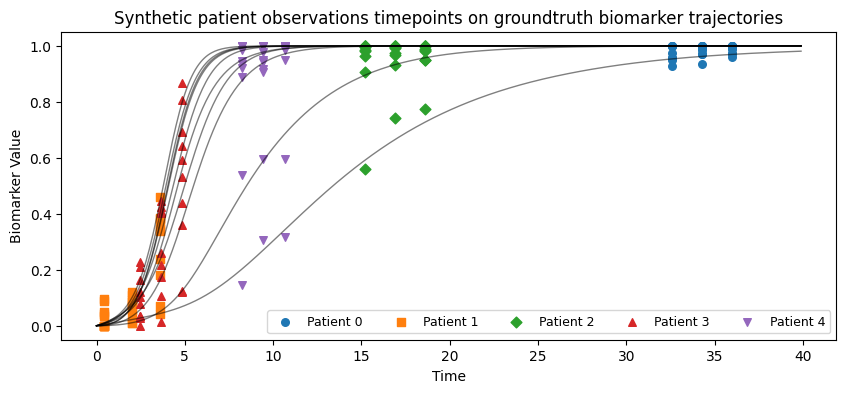

<class 'numpy.ndarray'> 300


In [ ]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.2, 0.5]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

X = []

for subtype in range(n_subtypes):
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
    )
    
    plot_true_observations(df, t, x_true)

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    label = np.ones(n_patients) * subtype # (n_patients)

    #print(f"dt shape: {dt.shape}\nids shape: {ids.shape}\ncog shape: {cog.shape}\nbeta shape: {beta_true.shape}")
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    X += X_subtype # pythonic concatenate list syntactic sugar

X = np.asarray(X)

In [ ]:
f_init = initialize_f_eigen(K=K) # TODO: make so that if just 1 eigen return list AND NOT list of lists
f_init = f_init[0]

em = EM(K=K, initial_f=f_init, jac_toggle=True, max_iter=30, t_max=t_max, epsilon=1e-1,
        lambda_f=1.0, lambda_cog=0.01, lambda_scalar=0.3)
em.fit(X)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 300 but corresponding boolean dimension is 900